# Experiment No. 5 — Feature Extraction and Image Analysis using SIFT and HOG Descriptors

* **Name:** Akshit Negi
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250214
* **SUBJECT:** Computer Vision Lab
* **SEM & Section:** 5th SEM, "B"

**Aim:** Implement SIFT and HOG feature extraction, visualize the descriptors, and compare their robustness and use cases.

Upload your own image in Step 1. For the matching step, we generate a rotated + scaled copy of your image to act as the "second similar image," so no extra upload is needed.

---

### Steps 1–2: Import libraries, upload image, preprocess

Saving Lord Of The Mysteries_诡秘之主_➤ Artist_Cre_on pic.jpeg to Lord Of The Mysteries_诡秘之主_➤ Artist_Cre_on pic.jpeg


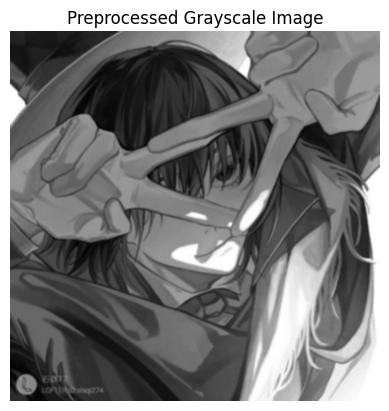

In [3]:
!pip install opencv-contrib-python -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from google.colab import files

uploaded = files.upload()                       # choose an image from your laptop
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.resize(img, (400, 400))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3, 3), 0)          # light denoise / preprocessing

plt.imshow(gray, cmap='gray'); plt.title("Preprocessed Grayscale Image"); plt.axis('off'); plt.show()

### Steps 3–4: Apply SIFT and visualize keypoints

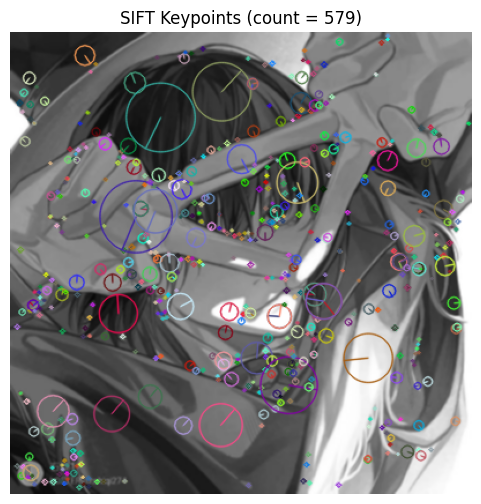

Descriptor shape (num_keypoints x 128): (579, 128)


In [4]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

sift_img = cv2.drawKeypoints(gray, keypoints, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(6, 6))
plt.imshow(sift_img)
plt.title(f"SIFT Keypoints (count = {len(keypoints)})")
plt.axis('off')
plt.show()

print("Descriptor shape (num_keypoints x 128):", descriptors.shape)

### Steps 5–6: Extract and visualize HOG features

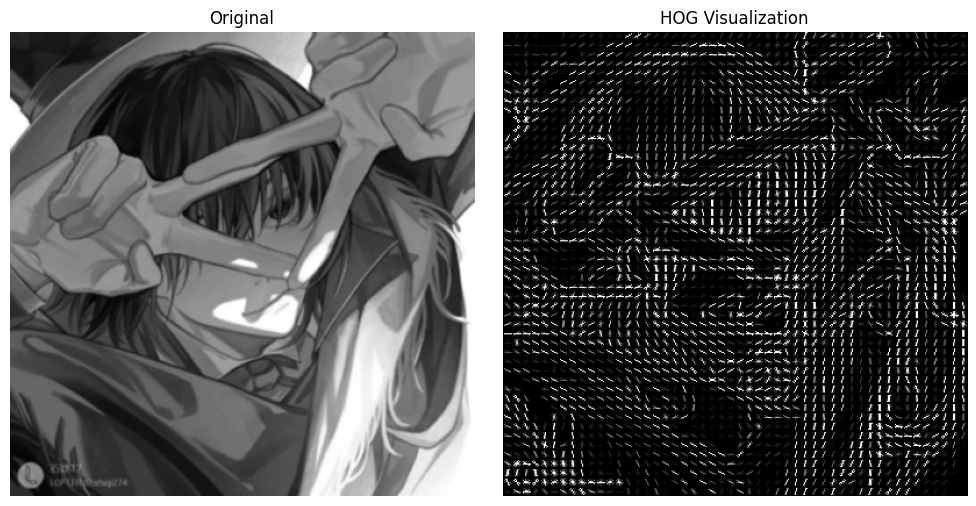

HOG feature vector length: 86436


In [5]:
hog_features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(hog_image_rescaled, cmap='gray'); plt.title("HOG Visualization"); plt.axis('off')
plt.tight_layout(); plt.show()

print("HOG feature vector length:", hog_features.shape[0])

### Step 7: Compare SIFT and HOG characteristics

| Property | SIFT | HOG |
|---|---|---|
| Scale invariance | Yes (built-in scale-space) | No (fixed cell/window size) |
| Rotation invariance | Yes (dominant orientation) | No (sensitive to rotation) |
| Output | Sparse keypoints + 128-D descriptors | Dense fixed-length feature vector |
| Speed | Slower (keypoint detection + description) | Faster, more predictable cost |
| Typical use | Matching, panorama stitching, 3D reconstruction | Pedestrian/object detection, classification |

### Step 8: Image matching using SIFT

We create a rotated + scaled version of the same image to simulate a "second similar image," then match SIFT keypoints between them using a Brute-Force matcher with ratio test.

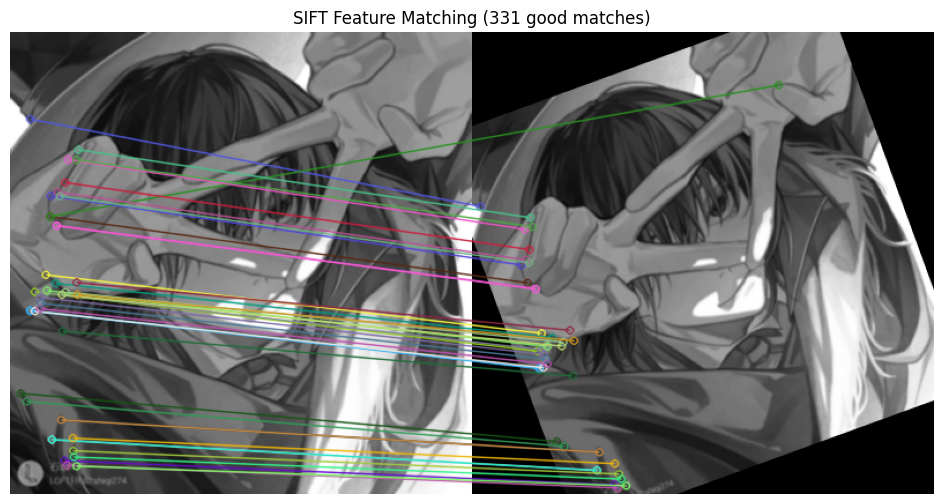

In [6]:
# Create a transformed "second" image: rotate 20 deg and scale down slightly
center = (gray.shape[1] // 2, gray.shape[0] // 2)
M = cv2.getRotationMatrix2D(center, 20, 0.9)
gray2 = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]))

kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors, des2, k=2)

# Lowe's ratio test to keep only good matches
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

match_img = cv2.drawMatches(gray, keypoints, gray2, kp2, good_matches[:40], None,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12, 6))
plt.imshow(match_img)
plt.title(f"SIFT Feature Matching ({len(good_matches)} good matches)")
plt.axis('off')
plt.show()

### Steps 9–10: Evaluation & Observations

- **SIFT** reliably matched keypoints even after rotation and scaling, confirming its scale/rotation invariance — ideal for image matching, stitching, and 3D reconstruction.
- **HOG** produced a dense, fixed-length descriptor that captures overall edge/gradient structure well, but is not invariant to rotation/scale, and is best suited to tasks like pedestrian/object detection where objects appear in a roughly consistent orientation.
- **Trade-off:** SIFT is more robust to geometric transformations but computationally heavier per image; HOG is fast, simple, and works well with classifiers like SVM for detection tasks, but requires fixed-size, roughly-aligned input windows.
- Handcrafted descriptors like these remain useful for lightweight or interpretable pipelines, though deep learning-based features now often outperform them for complex recognition tasks.

---

## Questions

**Q1. What is feature extraction, and why is it important in computer vision?**

**Ans:** Feature extraction is the process of transforming raw pixel data into a compact, meaningful representation (features/descriptors) that captures distinctive patterns like edges, corners, or textures. It's important because it reduces data dimensionality, highlights discriminative information, and provides the input representation needed for tasks like matching, classification, and detection.

**Q2. Explain the working principle of Scale-Invariant Feature Transform (SIFT).**

**Ans:** SIFT builds a scale-space by progressively blurring and downsampling the image (Gaussian pyramid), detects stable keypoints as extrema in the Difference-of-Gaussians across scales, assigns each keypoint a dominant orientation from local gradients, and finally encodes a 128-dimensional descriptor from gradient orientations in the keypoint's neighborhood — making the result robust to scale, rotation, and moderate illumination changes.

**Q3. What are keypoints and feature descriptors in image analysis?**

**Ans:** Keypoints are distinctive, repeatable locations in an image (such as corners or blobs) that can be reliably detected even under transformations. Feature descriptors are numerical vectors computed around each keypoint that encode local image information (like gradient patterns), enabling keypoints from different images to be compared and matched.

**Q4. Explain the concept of Histogram of Oriented Gradients (HOG) and its significance.**

**Ans:** HOG divides an image into small cells, computes a histogram of gradient orientations within each cell, and normalizes these histograms over larger blocks to form a single feature vector for the whole image/window. It's significant because it captures the shape and edge structure of objects (like the silhouette of a pedestrian) in a way that's robust to minor lighting changes, making it effective for detection tasks.

**Q5. Compare SIFT and HOG based on robustness, computational complexity, and practical applications.**

**Ans:** SIFT is robust to scale, rotation, and viewpoint changes but is computationally more expensive due to scale-space construction and keypoint description; it's used for image matching, panorama stitching, and 3D reconstruction. HOG is faster and simpler but not scale/rotation invariant, working best on fixed-size, roughly-aligned windows; it's widely used for pedestrian and object detection.

**Q6. Why is SIFT considered invariant to scale and rotation?**

**Ans:** SIFT detects keypoints across a multi-scale Gaussian pyramid, so the same physical feature is detected regardless of the image's scale, and it assigns each keypoint a dominant orientation based on local gradients, then computes the descriptor relative to that orientation — so rotating the image rotates the descriptor's reference frame along with it, keeping the descriptor itself consistent.

**Q7. Mention three real-world applications where HOG descriptors are commonly used.**

**Ans:** (1) Pedestrian detection in surveillance and autonomous vehicles, (2) vehicle/object detection in traffic monitoring systems, and (3) general object detection pipelines combined with classifiers like SVM (e.g., early face/person detectors).

**Q8. Why is feature extraction performed before image classification or object detection?**

**Ans:** Raw pixel values are high-dimensional and sensitive to noise, lighting, and minor shifts, making direct classification difficult. Feature extraction converts the image into a compact, more discriminative and often invariant representation, making it easier and more efficient for classifiers or detectors to distinguish between different objects or classes.

**Q9. What are the advantages and limitations of handcrafted feature descriptors compared to deep learning-based feature extraction?**

**Ans:** Handcrafted descriptors like SIFT and HOG are interpretable, computationally lightweight, need no training data, and work reasonably well in constrained settings. Their limitation is that they capture only predefined patterns (edges/gradients) and can struggle with complex variations in appearance. Deep learning-based feature extraction (CNNs) automatically learns hierarchical, task-specific features from large datasets, generally achieving much higher accuracy, but at the cost of requiring large labeled datasets, more computation, and reduced interpretability.

**Q10. How do feature extraction techniques contribute to image matching, face recognition, and object detection systems?**

**Ans:** They provide a consistent, comparable numerical representation of distinctive image regions, enabling systems to measure similarity between images (image matching), identify unique facial patterns despite pose/lighting variation (face recognition), and localize and classify objects by comparing extracted feature patterns against known templates or trained models (object detection).